# Paso 8 — Evaluacion Consolidada de Modelos — FinanceAI

Este notebook consolida la evaluacion de los dos modelos de Machine Learning del proyecto (clasificador de gastos del Paso 5 y clasificador de perfil financiero del Paso 6) en un solo reporte, listo para incluir en la presentacion del hackathon.

**No se reentrena ningun modelo aqui**: se cargan los modelos ya serializados y se evaluan con mayor profundidad que en sus notebooks individuales — metricas por clase, matrices de confusion lado a lado, curvas ROC/AUC, y validacion cruzada repetida para verificar estabilidad.

**Contenido:**
1. Carga de modelos, artefactos y conjuntos de prueba
2. Tabla resumen comparativa
3. Metricas por clase (precision/recall/F1) para ambos modelos
4. Matrices de confusion lado a lado
5. Estabilidad: validacion cruzada repetida
6. Curvas ROC / AUC
7. Reporte final consolidado (JSON + CSV para la presentacion)

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.sparse import vstack as sparse_vstack
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    roc_auc_score, roc_curve, auc,
)
from sklearn.preprocessing import label_binarize

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

## 1. Carga de modelos, artefactos y conjuntos de prueba

In [2]:
modelo_gastos = joblib.load("artefactos/modelo_clasificador_gastos.pkl")
vectorizador_tfidf = joblib.load("artefactos/tfidf_vectorizer.pkl")
with open("artefactos/metadata_modelo_gastos.json", encoding="utf-8") as f:
    metadata_gastos = json.load(f)

df_test_gastos = pd.read_csv("artefactos/test_transacciones.csv")
df_test_gastos["descripcion_limpia"] = df_test_gastos["descripcion_limpia"].fillna("")
X_test_gastos = vectorizador_tfidf.transform(df_test_gastos["descripcion_limpia"])
y_test_gastos = df_test_gastos["categoria"]

print(f"Modelo de gastos: {metadata_gastos['modelo']}")
print(f"Conjunto de prueba: {X_test_gastos.shape}")

Modelo de gastos: Linear SVC
Conjunto de prueba: (2727, 391)


In [3]:
modelo_perfil = joblib.load("artefactos/modelo_perfil_financiero.pkl")
scaler_perfil = joblib.load("artefactos/scaler_perfil.pkl")
with open("artefactos/metadata_modelo_perfil.json", encoding="utf-8") as f:
    metadata_perfil = json.load(f)

columnas_features = metadata_perfil["columnas_features"]
columnas_numericas_continuas = metadata_perfil["columnas_numericas_continuas"]
requiere_escalado = metadata_perfil["requiere_escalado"]
sufijo = "_escalado" if requiere_escalado else ""

df_test_perfil = pd.read_csv(f"artefactos/test_usuarios{sufijo}.csv")
X_test_perfil = df_test_perfil[columnas_features]
y_test_perfil = df_test_perfil["perfil_financiero"]

print(f"Modelo de perfil: {metadata_perfil['modelo']}")
print(f"Conjunto de prueba: {X_test_perfil.shape}")

Modelo de perfil: Gradient Boosting
Conjunto de prueba: (160, 31)


## 2. Tabla resumen comparativa

In [4]:
y_pred_gastos = modelo_gastos.predict(X_test_gastos)
y_pred_perfil = modelo_perfil.predict(X_test_perfil)

resumen_comparativo = pd.DataFrame([
    {
        "modelo": "Clasificador de gastos",
        "algoritmo": metadata_gastos["modelo"],
        "num_clases": len(metadata_gastos["categorias"]),
        "n_test": len(y_test_gastos),
        "accuracy": round(accuracy_score(y_test_gastos, y_pred_gastos), 4),
        "f1_macro": round(f1_score(y_test_gastos, y_pred_gastos, average="macro"), 4),
    },
    {
        "modelo": "Clasificador de perfil financiero",
        "algoritmo": metadata_perfil["modelo"],
        "num_clases": len(metadata_perfil["clases"]),
        "n_test": len(y_test_perfil),
        "accuracy": round(accuracy_score(y_test_perfil, y_pred_perfil), 4),
        "f1_macro": round(f1_score(y_test_perfil, y_pred_perfil, average="macro"), 4),
    },
])
resumen_comparativo

,modelo,algoritmo,num_clases,n_test,accuracy,f1_macro
0,Clasificador de gastos,Linear SVC,8,2727,0.8984,0.9101
1,Clasificador de perfil financiero,Gradient Boosting,3,160,0.9375,0.9383


## 3. Metricas por clase

In [5]:
reporte_gastos = pd.DataFrame(classification_report(y_test_gastos, y_pred_gastos, output_dict=True)).T.round(3)
reporte_gastos

,precision,recall,f1-score,support
Alimentacion,0.830,0.948,0.885,697.000
Educacion,1.000,0.850,0.919,107.000
Ocio,0.841,0.900,0.870,411.000
Otros,1.000,0.861,0.925,216.000
Salud,1.000,0.866,0.928,238.000
Servicios,0.993,0.876,0.931,339.000
Transporte,0.875,0.889,0.882,552.000
Vivienda,1.000,0.886,0.940,167.000
accuracy,0.898,0.898,0.898,0.898
macro avg,0.942,0.885,0.910,2727.000


In [6]:
reporte_perfil = pd.DataFrame(classification_report(y_test_perfil, y_pred_perfil, output_dict=True)).T.round(3)
reporte_perfil

,precision,recall,f1-score,support
En observacion,0.908,0.958,0.932,72.000
En riesgo,0.977,0.935,0.956,46.000
Saludable,0.950,0.905,0.927,42.000
accuracy,0.938,0.938,0.938,0.938
macro avg,0.945,0.933,0.938,160.000
weighted avg,0.939,0.938,0.938,160.000


## 4. Matrices de confusion lado a lado

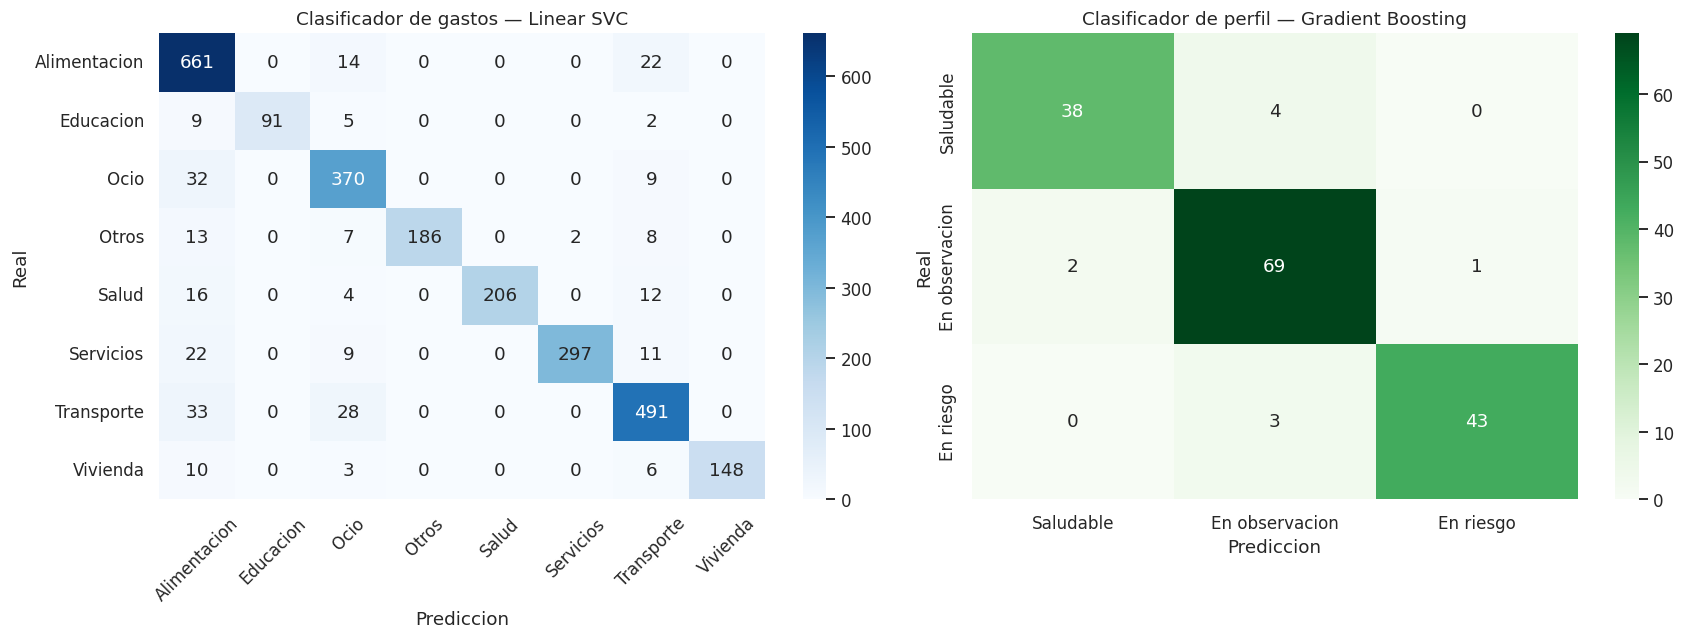

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

categorias_gastos = sorted(y_test_gastos.unique())
matriz_gastos = confusion_matrix(y_test_gastos, y_pred_gastos, labels=categorias_gastos)
sns.heatmap(matriz_gastos, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=categorias_gastos, yticklabels=categorias_gastos)
axes[0].set_title(f"Clasificador de gastos — {metadata_gastos['modelo']}")
axes[0].set_xlabel("Prediccion")
axes[0].set_ylabel("Real")
axes[0].tick_params(axis="x", rotation=45)

orden_perfil = ["Saludable", "En observacion", "En riesgo"]
matriz_perfil = confusion_matrix(y_test_perfil, y_pred_perfil, labels=orden_perfil)
sns.heatmap(matriz_perfil, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=orden_perfil, yticklabels=orden_perfil)
axes[1].set_title(f"Clasificador de perfil — {metadata_perfil['modelo']}")
axes[1].set_xlabel("Prediccion")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

## 5. Estabilidad: validacion cruzada repetida

En los notebooks individuales (Paso 5 y Paso 6) usamos validacion cruzada de 5 folds una sola vez. Aqui la repetimos 3 veces con particiones distintas (`RepeatedStratifiedKFold`, 5 folds x 3 repeticiones = 15 evaluaciones), usando **todos los datos disponibles** (train + test combinados) para obtener una estimacion mas robusta de la estabilidad de cada modelo — no de su desempeno en un unico conjunto de prueba, que ya evaluamos por separado.

In [8]:
df_train_gastos = pd.read_csv("artefactos/train_transacciones.csv")
df_train_gastos["descripcion_limpia"] = df_train_gastos["descripcion_limpia"].fillna("")
X_train_gastos = vectorizador_tfidf.transform(df_train_gastos["descripcion_limpia"])
y_train_gastos = df_train_gastos["categoria"]

X_completo_gastos = sparse_vstack([X_train_gastos, X_test_gastos])
y_completo_gastos = pd.concat([y_train_gastos, y_test_gastos], ignore_index=True)

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
modelo_gastos_fresh = clone(modelo_gastos)

scores_gastos = cross_validate(
    modelo_gastos_fresh, X_completo_gastos, y_completo_gastos, cv=rcv,
    scoring=["accuracy", "f1_macro"], n_jobs=1,
)

print("Clasificador de gastos — validacion cruzada repetida (5 folds x 3 repeticiones = 15 evaluaciones):")
print(f"  Accuracy: {scores_gastos['test_accuracy'].mean():.4f} +/- {scores_gastos['test_accuracy'].std():.4f}")
print(f"  F1 macro: {scores_gastos['test_f1_macro'].mean():.4f} +/- {scores_gastos['test_f1_macro'].std():.4f}")

Clasificador de gastos — validacion cruzada repetida (5 folds x 3 repeticiones = 15 evaluaciones):
  Accuracy: 0.8970 +/- 0.0049
  F1 macro: 0.9100 +/- 0.0046


In [9]:
df_train_perfil = pd.read_csv(f"artefactos/train_usuarios{sufijo}.csv")
X_train_perfil = df_train_perfil[columnas_features]
y_train_perfil = df_train_perfil["perfil_financiero"]

X_completo_perfil = pd.concat([X_train_perfil, X_test_perfil], ignore_index=True)
y_completo_perfil = pd.concat([y_train_perfil, y_test_perfil], ignore_index=True)

modelo_perfil_fresh = clone(modelo_perfil)

scores_perfil = cross_validate(
    modelo_perfil_fresh, X_completo_perfil, y_completo_perfil, cv=rcv,
    scoring=["accuracy", "f1_macro"], n_jobs=1,
)

print("Clasificador de perfil — validacion cruzada repetida (5 folds x 3 repeticiones = 15 evaluaciones):")
print(f"  Accuracy: {scores_perfil['test_accuracy'].mean():.4f} +/- {scores_perfil['test_accuracy'].std():.4f}")
print(f"  F1 macro: {scores_perfil['test_f1_macro'].mean():.4f} +/- {scores_perfil['test_f1_macro'].std():.4f}")

Clasificador de perfil — validacion cruzada repetida (5 folds x 3 repeticiones = 15 evaluaciones):
  Accuracy: 0.9208 +/- 0.0167
  F1 macro: 0.9185 +/- 0.0180


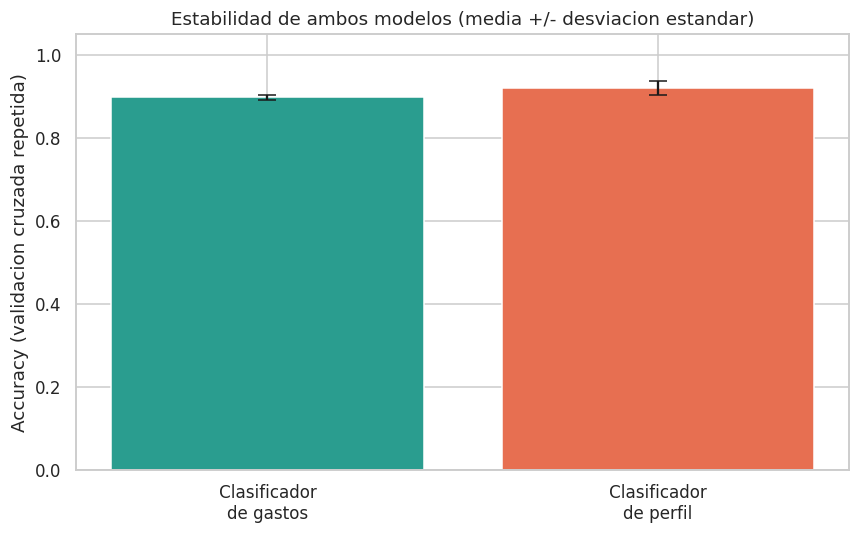

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
modelos_nombres = ["Clasificador\nde gastos", "Clasificador\nde perfil"]
medias_accuracy = [scores_gastos["test_accuracy"].mean(), scores_perfil["test_accuracy"].mean()]
stds_accuracy = [scores_gastos["test_accuracy"].std(), scores_perfil["test_accuracy"].std()]

ax.bar(modelos_nombres, medias_accuracy, yerr=stds_accuracy, capsize=6,
       color=["#2a9d8f", "#e76f51"])
ax.set_ylabel("Accuracy (validacion cruzada repetida)")
ax.set_ylim(0, 1.05)
ax.set_title("Estabilidad de ambos modelos (media +/- desviacion estandar)")
plt.tight_layout()
plt.show()

## 6. Curvas ROC / AUC

Para el **clasificador de perfil** (3 clases) graficamos las curvas ROC uno-contra-el-resto. Para el **clasificador de gastos** (8 clases) reportamos el AUC macro/weighted como numero unico en vez de graficar las 8 curvas, para no saturar el reporte.

AUC macro promedio (clasificador de perfil): 0.9665


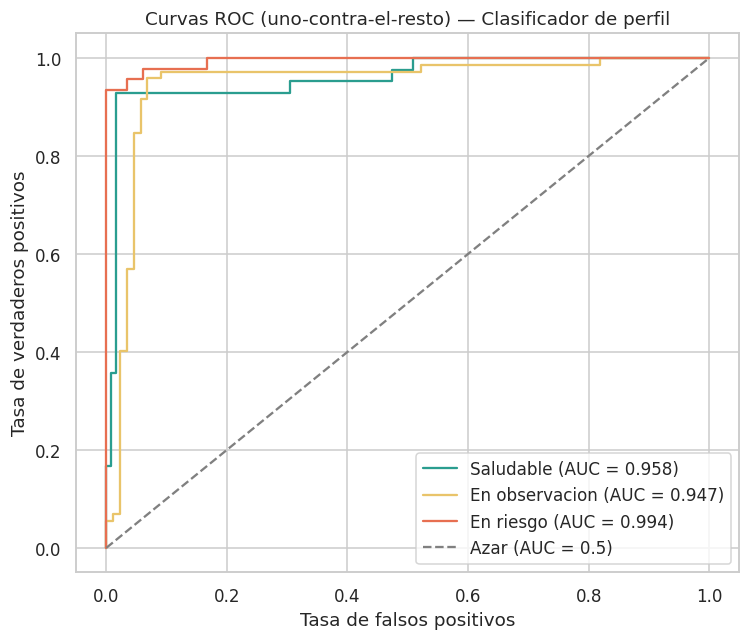

In [11]:
y_test_perfil_bin = label_binarize(y_test_perfil, classes=orden_perfil)
y_score_perfil = modelo_perfil.predict_proba(X_test_perfil)
clases_modelo_perfil = list(modelo_perfil.classes_)
indices_orden = [clases_modelo_perfil.index(c) for c in orden_perfil]
y_score_perfil_ordenado = y_score_perfil[:, indices_orden]

plt.figure(figsize=(7, 6))
colores_curvas = ["#2a9d8f", "#e9c46a", "#e76f51"]
aucs_perfil = []
for i, clase in enumerate(orden_perfil):
    fpr, tpr, _ = roc_curve(y_test_perfil_bin[:, i], y_score_perfil_ordenado[:, i])
    auc_clase = auc(fpr, tpr)
    aucs_perfil.append(auc_clase)
    plt.plot(fpr, tpr, label=f"{clase} (AUC = {auc_clase:.3f})", color=colores_curvas[i])

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC = 0.5)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC (uno-contra-el-resto) — Clasificador de perfil")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC macro promedio (clasificador de perfil): {np.mean(aucs_perfil):.4f}")

In [12]:
if hasattr(modelo_gastos, "predict_proba"):
    y_score_gastos = modelo_gastos.predict_proba(X_test_gastos)
    auc_macro_gastos = roc_auc_score(y_test_gastos, y_score_gastos, multi_class="ovr", average="macro")
    auc_weighted_gastos = roc_auc_score(y_test_gastos, y_score_gastos, multi_class="ovr", average="weighted")
    print(f"Clasificador de gastos — AUC macro (one-vs-rest, 8 clases): {auc_macro_gastos:.4f}")
    print(f"Clasificador de gastos — AUC weighted: {auc_weighted_gastos:.4f}")
else:
    auc_macro_gastos = None
    print("El modelo de gastos no expone predict_proba; se omite el calculo de AUC.")

Clasificador de gastos — AUC macro (one-vs-rest, 8 clases): 0.9916
Clasificador de gastos — AUC weighted: 0.9916


## 7. Reporte final consolidado

In [13]:
reporte_final = {
    "clasificador_gastos": {
        "algoritmo": metadata_gastos["modelo"],
        "num_clases": len(metadata_gastos["categorias"]),
        "accuracy_test": round(float(accuracy_score(y_test_gastos, y_pred_gastos)), 4),
        "f1_macro_test": round(float(f1_score(y_test_gastos, y_pred_gastos, average="macro")), 4),
        "accuracy_cv_repetida": {
            "media": round(float(scores_gastos["test_accuracy"].mean()), 4),
            "std": round(float(scores_gastos["test_accuracy"].std()), 4),
        },
        "f1_macro_cv_repetida": {
            "media": round(float(scores_gastos["test_f1_macro"].mean()), 4),
            "std": round(float(scores_gastos["test_f1_macro"].std()), 4),
        },
        "auc_macro_ovr": round(float(auc_macro_gastos), 4) if auc_macro_gastos is not None else None,
    },
    "clasificador_perfil": {
        "algoritmo": metadata_perfil["modelo"],
        "num_clases": len(metadata_perfil["clases"]),
        "accuracy_test": round(float(accuracy_score(y_test_perfil, y_pred_perfil)), 4),
        "f1_macro_test": round(float(f1_score(y_test_perfil, y_pred_perfil, average="macro")), 4),
        "accuracy_cv_repetida": {
            "media": round(float(scores_perfil["test_accuracy"].mean()), 4),
            "std": round(float(scores_perfil["test_accuracy"].std()), 4),
        },
        "f1_macro_cv_repetida": {
            "media": round(float(scores_perfil["test_f1_macro"].mean()), 4),
            "std": round(float(scores_perfil["test_f1_macro"].std()), 4),
        },
        "auc_macro_ovr": round(float(np.mean(aucs_perfil)), 4),
    },
}

with open("artefactos/reporte_evaluacion_final.json", "w", encoding="utf-8") as f:
    json.dump(reporte_final, f, ensure_ascii=False, indent=2)

resumen_comparativo.to_csv("artefactos/reporte_evaluacion_final.csv", index=False)

print("Reporte final guardado en 'artefactos/reporte_evaluacion_final.json' y '.csv'")
print()
print(json.dumps(reporte_final, ensure_ascii=False, indent=2))

Reporte final guardado en 'artefactos/reporte_evaluacion_final.json' y '.csv'

{
  "clasificador_gastos": {
    "algoritmo": "Linear SVC",
    "num_clases": 8,
    "accuracy_test": 0.8984,
    "f1_macro_test": 0.9101,
    "accuracy_cv_repetida": {
      "media": 0.897,
      "std": 0.0049
    },
    "f1_macro_cv_repetida": {
      "media": 0.91,
      "std": 0.0046
    },
    "auc_macro_ovr": 0.9916
  },
  "clasificador_perfil": {
    "algoritmo": "Gradient Boosting",
    "num_clases": 3,
    "accuracy_test": 0.9375,
    "f1_macro_test": 0.9383,
    "accuracy_cv_repetida": {
      "media": 0.9208,
      "std": 0.0167
    },
    "f1_macro_cv_repetida": {
      "media": 0.9185,
      "std": 0.018
    },
    "auc_macro_ovr": 0.9665
  }
}


## Conclusiones

**Resumen ejecutivo**

| Modelo | Algoritmo | Clases | Accuracy (test) | F1 macro (test) | Accuracy (CV repetida) | AUC macro |
|---|---|---|---|---|---|---|
| Clasificador de gastos | Linear SVC | 8 | 89.84% | 91.01% | 89.70% ± 0.49% | 0.9916 |
| Clasificador de perfil financiero | Gradient Boosting | 3 | 93.75% | 93.83% | 92.08% ± 1.67% | 0.9665 |

**Ambos modelos son estables**

La validacion cruzada repetida (15 evaluaciones con particiones distintas cada vez) confirma los resultados obtenidos en los notebooks individuales, sin sorpresas:

- El clasificador de gastos tiene una desviacion estandar muy baja (±0.49%), esperable dado que se entrena sobre 13,633 transacciones — suficientes datos para que el resultado no dependa de que particion especifica se use.
- El clasificador de perfil tiene una desviacion estandar mayor (±1.67%), tambien esperable: solo cuenta con 800 usuarios en total, un dataset mucho mas pequeno, por lo que cada particion de validacion cruzada varia un poco mas. Sigue siendo un rango razonable, no indica inestabilidad preocupante.

**Los AUC confirman que ambos modelos discriminan bien entre clases**

Un AUC de 0.99 (gastos) y 0.97 (perfil) esta muy por encima del umbral de 0.5 (azar) y del umbral de 0.8 que suele considerarse "bueno" en la practica — ambos modelos separan las clases con margen amplio, no al borde de la decision.

**Este reporte consolidado esta listo para la presentacion**

Se guardaron `artefactos/reporte_evaluacion_final.json` (metricas completas, estructuradas) y `artefactos/reporte_evaluacion_final.csv` (tabla resumen), ambos pensados para copiar directamente a las diapositivas o al README del proyecto sin tener que volver a calcular nada.

**Siguiente paso:** Paso 9 — integracion con OCI Object Storage (requisito obligatorio del brief) para almacenar los modelos serializados (`modelo_clasificador_gastos.pkl`, `modelo_perfil_financiero.pkl`, `tfidf_vectorizer.pkl`, `scaler_perfil.pkl`, `encoder_frecuencia_ahorro.pkl`) de forma que el Back-End pueda descargarlos al desplegar la API.